In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Updated filename to match your directory
df = pd.read_csv("data/kenya_clean.csv") 

# This might not even be needed if you already cleaned it, 
# but it doesn't hurt to keep:
df.replace(-999, np.nan, inplace=True) 

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya,2015-01-01,1
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,2015-01-02,1
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,2015-01-03,1
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,2015-01-04,1
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,2015-01-05,1


In [15]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,6.423564
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,3.477046
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,12.000000


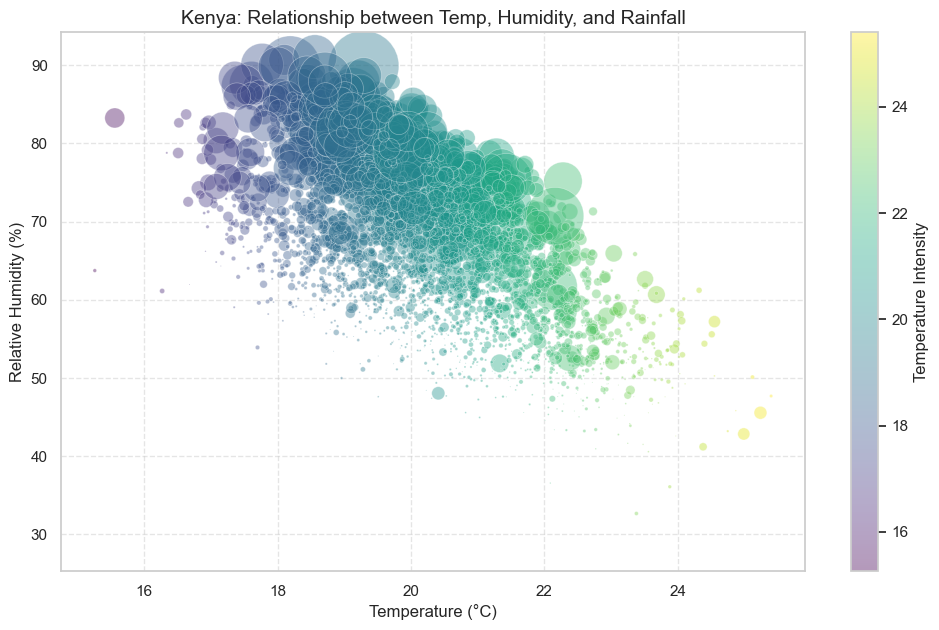

In [16]:
plt.figure(figsize=(12, 7))

# Creating the bubble chart
plt.scatter(
    x=df['T2M'], 
    y=df['RH2M'], 
    s=df['PRECTOTCORR'] * 50,  # Larger multiplier for better visibility
    c=df['T2M'],               # Color based on temperature
    cmap='viridis', 
    alpha=0.4, 
    edgecolors="w", 
    linewidth=0.5
)

plt.title('Kenya: Relationship between Temp, Humidity, and Rainfall', fontsize=14)
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Relative Humidity (%)', fontsize=12)
plt.colorbar(label='Temperature Intensity')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

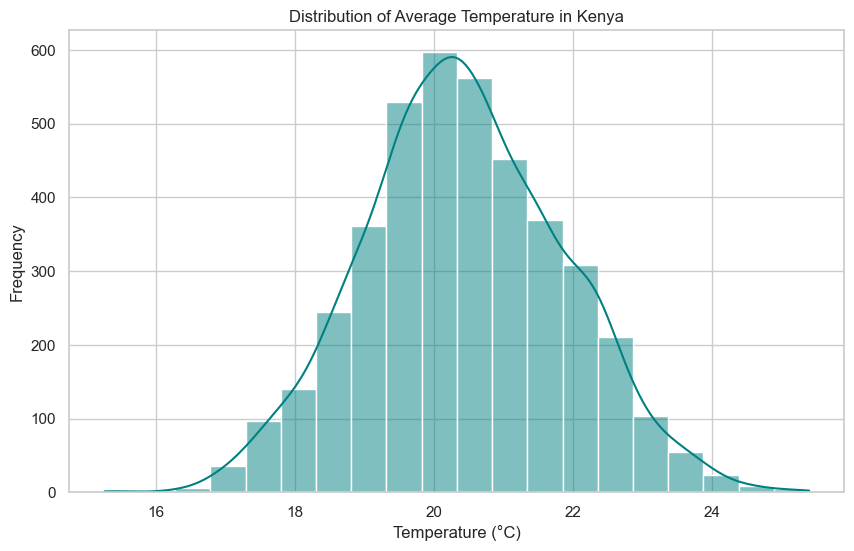

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(df['T2M'], bins=20, kde=True, color='teal')
plt.title('Distribution of Average Temperature in Kenya')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.show()

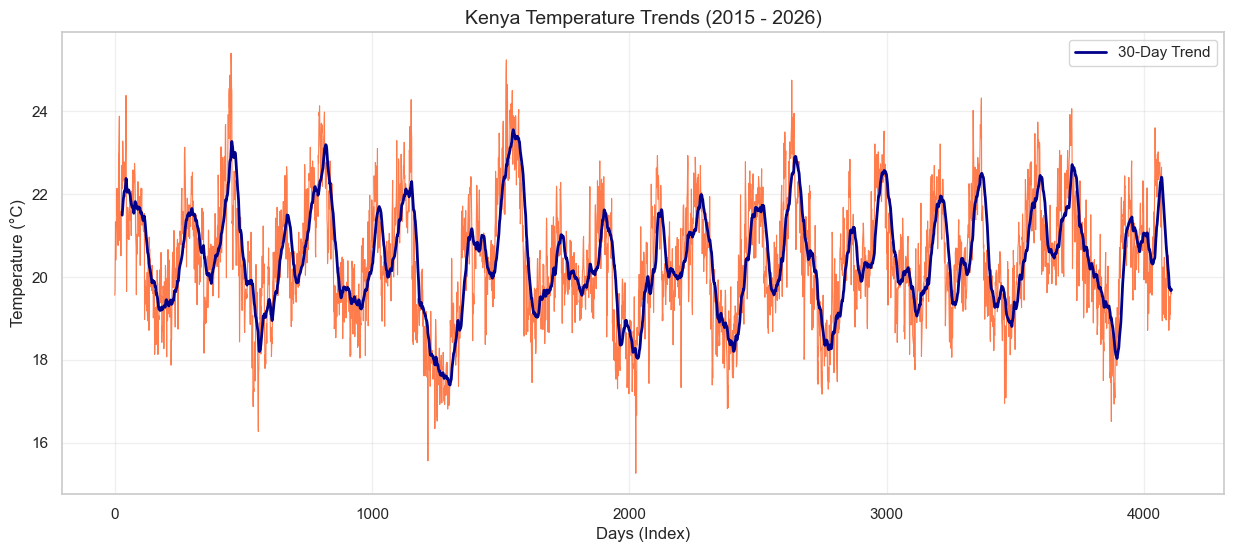

In [18]:
plt.figure(figsize=(15, 6))

# Plotting Temperature over the timeline
plt.plot(df.index, df['T2M'], color='orangered', linewidth=0.8, alpha=0.7)

# Adding a rolling average (trend line) to see the long-term move
plt.plot(df['T2M'].rolling(window=30).mean(), color='darkblue', linewidth=2, label='30-Day Trend')

plt.title('Kenya Temperature Trends (2015 - 2026)', fontsize=14)
plt.xlabel('Days (Index)', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

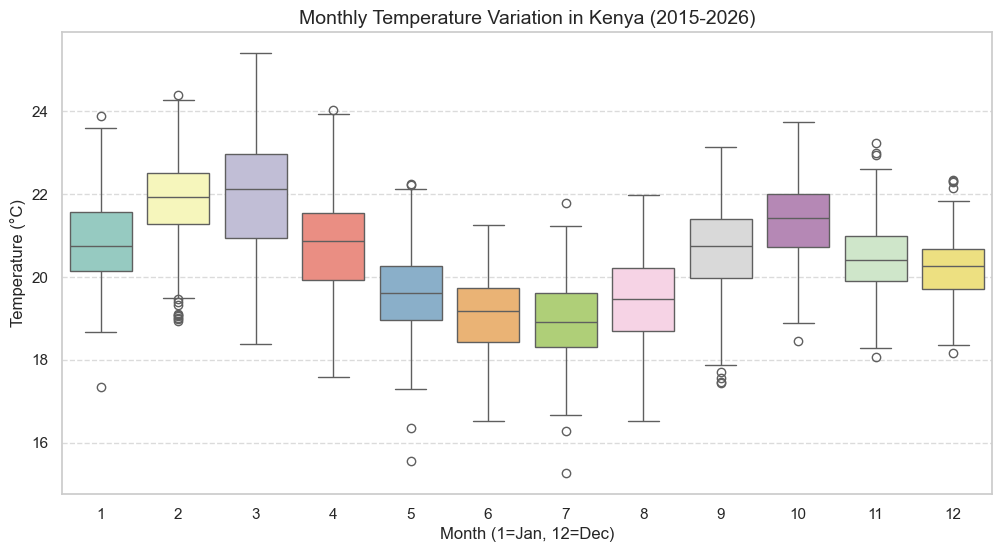

In [20]:
plt.figure(figsize=(12, 6))

# Fixed the warning by adding hue and legend=False
sns.boxplot(x='Month', y='T2M', data=df, hue='Month', palette='Set3', legend=False)

plt.title('Monthly Temperature Variation in Kenya (2015-2026)', fontsize=14)
plt.xlabel('Month (1=Jan, 12=Dec)', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [22]:
import warnings
warnings.filterwarnings('ignore')

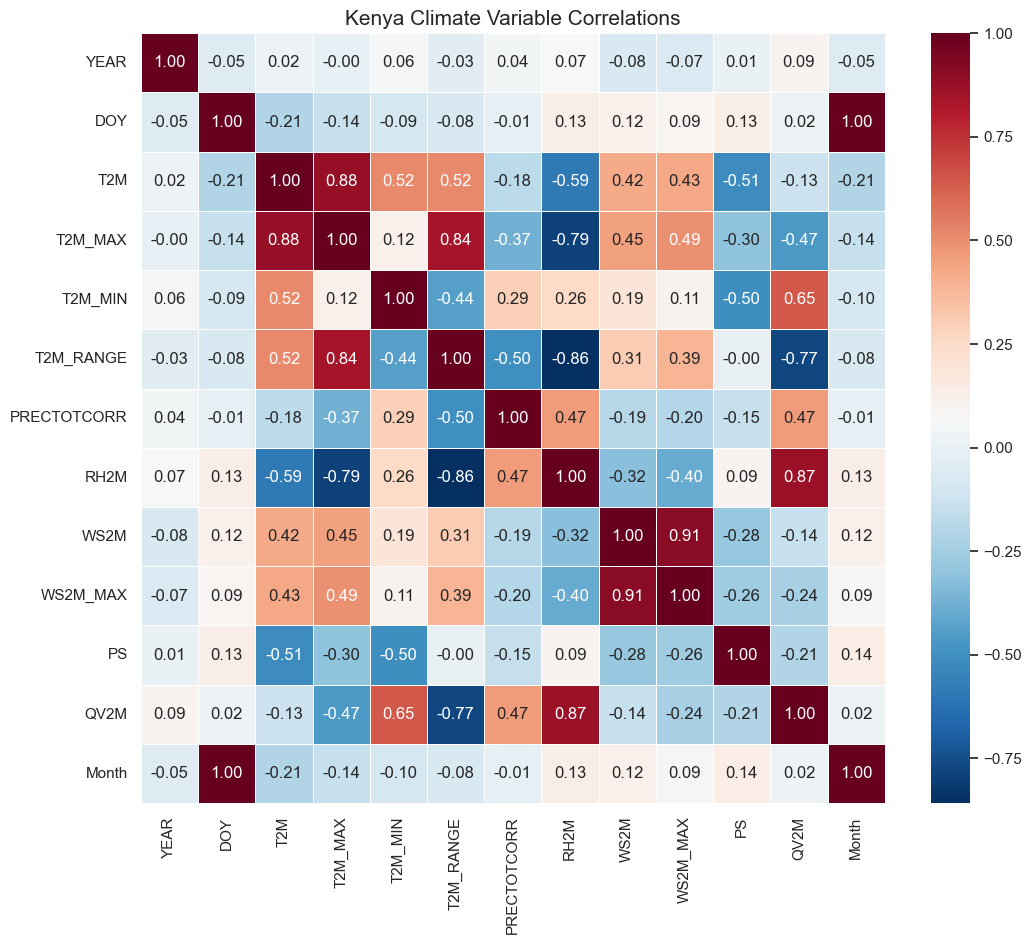

In [23]:
plt.figure(figsize=(12, 10))

# Using numeric_only=True to avoid the error we saw in Sudan
corr_kenya = df.corr(numeric_only=True)

# Plotting with a slightly different color map (optional, but looks nice!)
sns.heatmap(corr_kenya, annot=True, cmap='RdBu_r', fmt=".2f", linewidths=0.5)

plt.title('Kenya Climate Variable Correlations', fontsize=15)
plt.show()